# 3. A portfolio with a risky and a safe asset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# plot settings
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': 0.25, 'grid.linestyle': '-'})
plt.rcParams.update({'font.size': 12})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from PortfolioModel import PortfolioModelClass

model = PortfolioModelClass()  # default parameters, as in the assignment
par = model.par
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


## 3.1

In [2]:
R = model.draw_returns() # draw returns
print(f'R has shape {R.shape}')

R has shape (50000, 40)


In [3]:
logR = np.log(R)

print(f'mean of log R_t:  {logR.mean():.4f}   (mu = {par.mu:.4f})\n'
      f'std of log R_t:   {logR.std():.4f}   (sigma = {par.sigma:.4f})\n\n'
      f'mean of R_t:                 {R.mean():.4f}\n'
      f'exp(mu + 0.5*sigma**2):      {np.exp(par.mu+0.5*par.sigma**2):.4f}')

mean of log R_t:  0.0500   (mu = 0.0500)
std of log R_t:   0.2000   (sigma = 0.2000)

mean of R_t:                 1.0725
exp(mu + 0.5*sigma**2):      1.0725


Both checks match closely: the mean and standard deviation of
$\log R_t$ are close to $\mu$ and $\sigma$, and the mean of $R_t$ is close
to $\exp(\mu+\tfrac12\sigma^2)$, as expected for a lognormal variable.

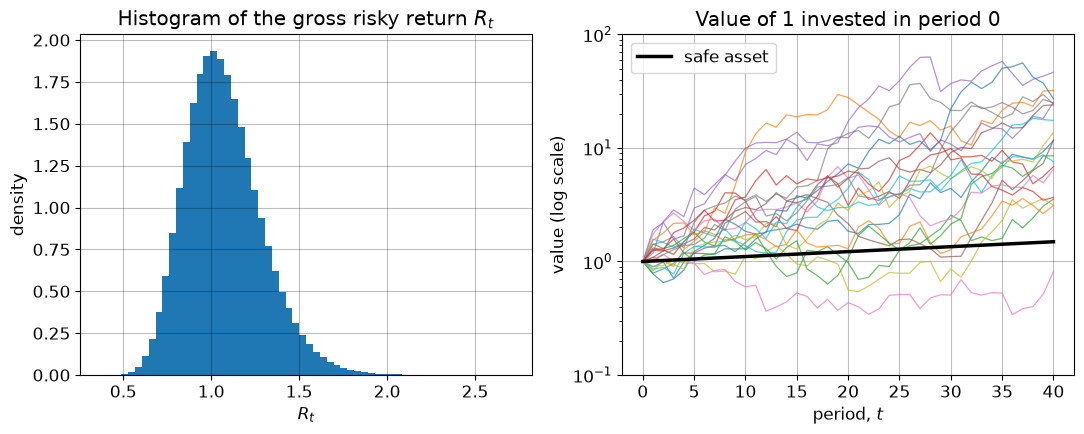

In [4]:
Rf = np.exp(par.r)

# value of 1 invested in period 0 and never traded: V_0=1, V_{t+1}=V_t*R_t
V_risky = np.empty((par.N, par.T + 1))
V_risky[:, 0] = 1.0
V_safe = np.empty(par.T + 1)
V_safe[0] = 1.0
for t in range(par.T):
    V_risky[:, t + 1] = V_risky[:, t] * R[:, t]
    V_safe[t + 1] = V_safe[t] * Rf

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. histogram of the gross risky return. R has shape (N,T); reshape(-1)
#    turns it into one long 1D array of all the draws, for one histogram.
axes[0].hist(R.reshape(-1), bins=60, density=True, color=colors[0])
axes[0].set_title('Histogram of the gross risky return $R_t$')
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('density')

# ii. value of 1 invested in period 0, log scale
# y-limits fixed to 0.1-100, so the log axis gets clean labeled ticks
t_grid = np.arange(par.T + 1)
for i in range(20):
    axes[1].plot(t_grid, V_risky[i, :], lw=0.9, color=colors[i % len(colors)], alpha=0.7)
axes[1].plot(t_grid, V_safe, lw=2.5, color='black', label='safe asset')
axes[1].set_yscale('log')
axes[1].set_ylim(0.1, 100)
axes[1].set_title('Value of 1 invested in period 0')
axes[1].set_xlabel('period, $t$')
axes[1].set_ylabel('value (log scale)')
axes[1].legend(loc='upper left')

fig.tight_layout()
fig.savefig('q1_returns.png')
plt.show()

Panel i) is bell-shaped and centered a little above 1, since $R_t$ is
built from a normal shock $\varepsilon_t$: it is the histogram of
$\exp(\mu+\sigma\varepsilon_t)$, and $\exp$ turns the symmetric normal
shape into a slightly right-skewed one, with a longer tail on the high side
than the low side.

In panel ii), each coloured line is one of the 20 risky-asset portfolios,
and the thick black line is the safe asset, which grows at a constant rate
(a straight line on the log scale). The risky paths trend up on average,
since the risky asset has a higher expected return, but they are spread
out, and some end up below the safe asset even after 40 periods.

## 3.2

In [5]:
# Delta and tau are set on each model, not passed to .simulate(), so we
# need one model per rule. Both use the same R, so they are comparable.
model_d0 = PortfolioModelClass(Delta=0.0, tau=0.0)
sim_d0 = model_d0.simulate(R=R)
summary_d0 = model_d0.summary()

model_d1 = PortfolioModelClass(Delta=1.0, tau=0.0)
sim_d1 = model_d1.simulate(R=R)
summary_d1 = model_d1.summary()

table_extremes = pd.DataFrame(
    [summary_d0, summary_d1],
    index=['delta=0 (trade every period)', 'delta=1 (never trade)'],
)
table_extremes

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,E[u(WT)]
delta=0 (trade every period),39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
delta=1 (never trade),0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


With τ=0, trading is free. Δ=0 rebalances almost every period (39/40) and stays close to target. Δ=1 never trades, so the risky share drifts, increasing both distance from target and spread in terminal wealth. The drift raises mean terminal wealth (5.04 → 8.98) since the risky asset earns more, but lowers the 10th percentile and expected utility, since CRRA (γ=3) penalizes the extra downside risk.

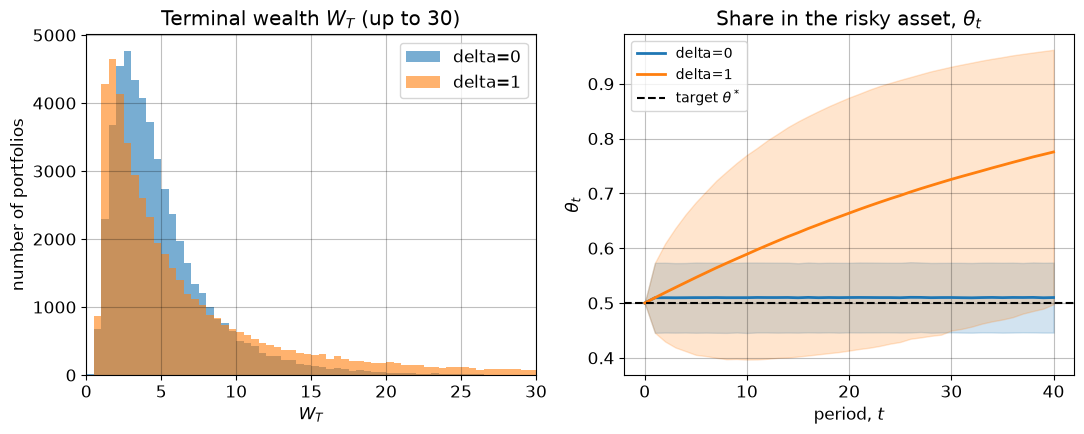

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. histogram of terminal wealth for both rules, up to W_T=30
# (a few portfolios go higher; the text below reports how many)
wealth_bins = np.linspace(0, 30, 61)
axes[0].hist(sim_d0.W[-1, :], bins=wealth_bins, alpha=0.6, color=colors[0], label='delta=0')
axes[0].hist(sim_d1.W[-1, :], bins=wealth_bins, alpha=0.6, color=colors[1], label='delta=1')
axes[0].set_xlim(0, 30)
axes[0].set_title('Terminal wealth $W_T$ (up to 30)')
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('number of portfolios')
axes[0].legend()

# ii. mean theta_t over time, with a 10th-90th percentile band across portfolios
t_grid = np.arange(par.T + 1)
for sim, label, c in [(sim_d0, 'delta=0', colors[0]), (sim_d1, 'delta=1', colors[1])]:
    theta_mean = sim.theta.mean(axis=1)
    theta_lo = np.percentile(sim.theta, 10, axis=1)
    theta_hi = np.percentile(sim.theta, 90, axis=1)
    axes[1].fill_between(t_grid, theta_lo, theta_hi, color=c, alpha=0.2)
    axes[1].plot(t_grid, theta_mean, color=c, lw=2, label=label)
axes[1].axhline(par.theta_star, ls='--', lw=1.5, color='black', label=r'target $\theta^*$')
axes[1].set_title(r'Share in the risky asset, $\theta_t$')
axes[1].set_xlabel('period, $t$')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].legend(loc='upper left', fontsize=10)

fig.tight_layout()
fig.savefig('q2_extremes.png')
plt.show()

In [7]:
# theta_t for delta=1 at three points in time
theta1_start = sim_d1.theta[0, :]
theta1_mid = sim_d1.theta[par.T // 4, :]
theta1_end = sim_d1.theta[-1, :]

print(f'delta=1, theta_t: mean (std) at t=0:              {theta1_start.mean():.4f} ({theta1_start.std():.4f})\n'
      f'delta=1, theta_t: mean (std) at t={par.T // 4}:               {theta1_mid.mean():.4f} ({theta1_mid.std():.4f})\n'
      f'delta=1, theta_t: mean (std) at t={par.T} (last period): {theta1_end.mean():.4f} ({theta1_end.std():.4f})')

delta=1, theta_t: mean (std) at t=0:              0.5000 (0.0000)
delta=1, theta_t: mean (std) at t=10:               0.5890 (0.1416)
delta=1, theta_t: mean (std) at t=40 (last period): 0.7756 (0.1870)


The mean θ_t rises from 0.50 to about 0.78, since the risky asset earns more and nothing pulls it back. The spread grows to about 0.19 as portfolios diverge. Δ=0's θ_t isn't exactly 0.50 either (~0.51, measured pre-trade), but that drift is tiny by comparison.

## 3.3

In [8]:
deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

# one model per delta, all using the same R
rows3 = []
for d in deltas:
    m = PortfolioModelClass(Delta=d, tau=0.01)
    m.simulate(R=R)
    rows3.append(m.summary())

table3 = pd.DataFrame(rows3, index=deltas)
table3.index.name = 'delta'
table3

,n_trades,avg_dist,mean_WT,median_WT,p10_WT,E[u(WT)]
delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


Panel i) has both the number of trades and the average distance to target,
on the same axis (the distance is turned into percentage points, i.e.
multiplied by 100, so both lines are on a similar scale). Panel ii) has
expected utility.

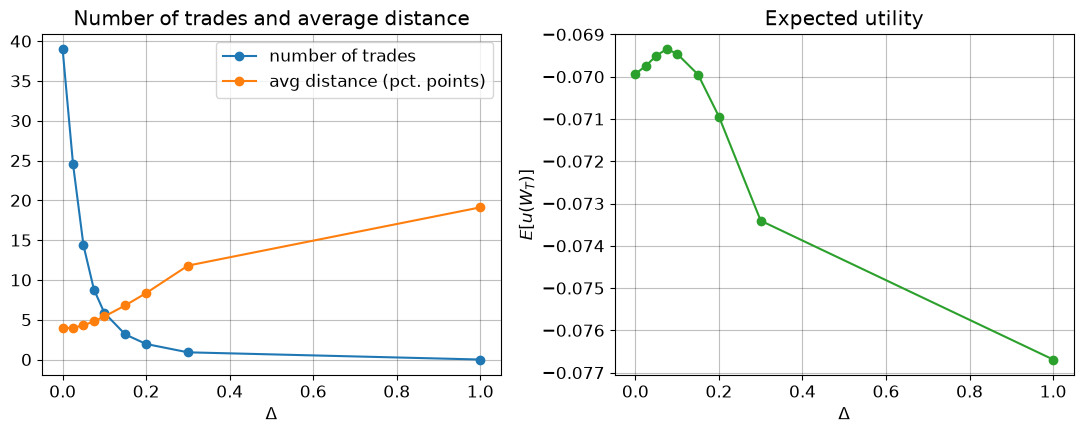

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# i. number of trades and average distance (in percentage points), same axis
axes[0].plot(table3.index, table3['n_trades'], marker='o', color=colors[0], label='number of trades')
axes[0].plot(table3.index, table3['avg_dist'] * 100, marker='o', color=colors[1], label='avg distance (pct. points)')
axes[0].set_title('Number of trades and average distance')
axes[0].set_xlabel(r'$\Delta$')
axes[0].legend()

# ii. expected utility
axes[1].plot(table3.index, table3['E[u(WT)]'], marker='o', color=colors[2])
axes[1].set_title('Expected utility')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel(r'$E[u(W_T)]$')

fig.tight_layout()
fig.savefig('q3_grid.png')
plt.show()

In [10]:
# the delta with the highest expected utility
best_i = np.argmax(table3['E[u(WT)]'].values)
best_delta = table3.index[best_i]
best_row = table3.loc[best_delta]

print(f"best delta (by expected utility): {best_delta}\n"
      f"E[u(WT)] at best delta: {best_row['E[u(WT)]']:.6f}\n"
      f"E[u(WT)] at delta=0:    {table3.loc[0.0, 'E[u(WT)]']:.6f}   (beaten by {best_row['E[u(WT)]']-table3.loc[0.0,'E[u(WT)]']:.6f})\n"
      f"E[u(WT)] at delta=1:    {table3.loc[1.0, 'E[u(WT)]']:.6f}   (beaten by {best_row['E[u(WT)]']-table3.loc[1.0,'E[u(WT)]']:.6f})")

best delta (by expected utility): 0.075
E[u(WT)] at best delta: -0.069347
E[u(WT)] at delta=0:    -0.069934   (beaten by 0.000588)
E[u(WT)] at delta=1:    -0.076690   (beaten by 0.007343)


The numbers below are all from the table in section 1 above.

From Δ=0 to the best Δ: trades drop sharply (39 → under 9), while distance to target barely rises (0.04 → 0.05) and wealth (mean, median, 10th percentile) barely changes. Expected utility improves only slightly. So a small band mainly saves on trading costs.

Ranking by mean W_T instead disagrees: it keeps rising toward Δ=1, since a wider band lets the risky share drift up toward its higher return — but that ignores the extra downside risk, which is exactly what expected utility penalizes.